# Feature Engineering 

Análisis exploratorio para el diseño de features del modelo de forecast de `prod_pet` (petróleo, horizonte t+1).

**Reglas que sigue este notebook:**

- Todo el análisis se hace **solo sobre `train`** (periodo ≤ 2023-07-01, ADR-028). No se mira `val` ni `test` — ni siquiera para definir qué pozos entran.
- El **universo** es petrolero: pozos con al menos un mes de `prod_pet > 0`, calculado **dentro de train**.
- Las funciones y el diccionario de columnas viven en `ml/eda.py` (no se define lógica inline acá).
- Las fechas de corte salen de `ml/config.py`, idénticas a las del modelado.

## Índice
1. Carga del dataset crudo (train) y primeras filas
2. Diccionario de columnas — qué significa cada una
3. Nulls por columna cruda
4. Selección de columnas a analizar — qué tiene sentido graficar y qué se descarta
5. Histogramas — variables numéricas
6. Frecuencias — variables categóricas
7. ¿Qué columnas entran al modelo? — decisión de inputs (distinta de la del EDA)
8. Correlación entre las features numéricas
9. Correlación de las categóricas (one-hot) con el target
10. Construcción del dataset básico procesado (anti-leakage, features del mes anterior)

In [1]:
import sys
from pathlib import Path

# permite importar el paquete `ml` desde el notebook (raíz del repo en el path)
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from ml.config import TRAIN_END
from ml import eda
from ml import dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)  # no truncar descripciones largas

## 1. Carga del dataset crudo (train) y primeras filas

Cargamos las **40 columnas crudas** del export de producción, recortadas a train y al universo petrolero (ver `ml/eda.load_train_raw`).

In [2]:
train = eda.load_train_raw()

print(f"Filas (train, universo petrolero): {len(train):,}")
print(f"Pozos únicos:                      {train['idpozo'].nunique():,}")
print(f"Columnas crudas:                   {train.shape[1] - 1}  (+ 'periodo' derivada)")
print(f"Rango temporal:                    {train['periodo'].min().date()}  ->  {train['periodo'].max().date()}")
print(f"Corte de train (TRAIN_END):        {TRAIN_END.date()}")

Filas (train, universo petrolero): 224,166
Pozos únicos:                      3,018
Columnas crudas:                   40  (+ 'periodo' derivada)
Rango temporal:                    2006-01-01  ->  2023-07-01
Corte de train (TRAIN_END):        2023-07-01


**Primeras filas.** Con 40 columnas, la vista normal queda ilegible a lo ancho; la mostramos **transpuesta** (una columna por fila) para leer de un vistazo qué trae cada campo en los primeros registros.

In [3]:
train.head(5).T

,0,1,2,3,4
idempresa,PEL,PEL,PEL,PEL,PEL
anio,2006,2006,2006,2006,2006
mes,2,3,4,5,6
idpozo,3640,3640,3640,3640,3640
prod_pet,0.0,30.808,76.609,63.273,55.043
prod_gas,0.0,1.731,3.713,4.202,4.373
prod_agua,0.0,30.57,46.479,50.536,52.062
iny_agua,0.0,0.0,0.0,0.0,0.0
iny_gas,0.0,0.0,0.0,0.0,0.0
iny_co2,0.0,0.0,0.0,0.0,0.0


## 2. Diccionario de columnas — qué significa cada una

Descripción de las 40 columnas crudas, con su **rol** (identificador, temporal, medida, categórica, atributo del pozo, geografía o metadata) y su **unidad** cuando aplica. El target (`prod_pet`) queda marcado en su descripción.

Fuente: Secretaría de Energía (data.gob.ar) — producción mensual de pozos de gas y petróleo. Definición canónica del modelo dimensional en [`docs/data-model.md`](../docs/data-model.md).

In [4]:
eda.data_dictionary()

,rol,unidad,descripción
columna,,,
idpozo,identificador,—,ID único del pozo (clave natural del pozo).
idempresa,identificador,—,ID de la empresa operadora (clave natural de la operadora).
idusuario,metadata,—,ID del usuario que cargó/rectificó el registro.
idareapermisoconcesion,identificador,—,ID del área de permiso/concesión.
idareayacimiento,identificador,—,ID del yacimiento/área (clave natural del yacimiento).
anio,temporal,año,Año del registro de producción.
mes,temporal,1-12,Mes del registro de producción.
fechaingreso,metadata,fecha,Fecha de ingreso del registro al sistema de la Secretaría.
fecha_data,metadata,fecha,Fecha/versión del dato (usada para deduplicar rectificaciones).


Si querés ver el conteo por rol (cuántas columnas son medidas, categóricas, etc.):

In [5]:
eda.data_dictionary()["rol"].value_counts().rename("n_columnas").to_frame()

,n_columnas
rol,
categórica,15
medida,8
metadata,6
identificador,4
atributo_pozo,3
temporal,2
geografía,2


## 3. Nulls por columna cruda

Cuántos valores faltantes tiene cada columna en train, en % sobre las 224.166 filas. Ordenado de mayor a menor; la barra es ayuda visual del porcentaje.

> Nota: las medidas numéricas se castean con `errors="coerce"` al cargar, así que cualquier valor no numérico en origen también cuenta como null.

In [6]:
eda.null_report_styled(train)

,rol,dtype,n_nulls,pct_null
columna,,,,
vida_util,atributo_pozo,float64,"220,424",98.33%
observaciones,metadata,object,"211,690",94.43%
subclasificacion,categórica,object,778,0.35%
clasificacion,categórica,object,778,0.35%
tipoextraccion,categórica,object,369,0.16%
tipopozo,categórica,object,369,0.16%
tipoestado,categórica,object,369,0.16%
sub_tipo_recurso,categórica,object,308,0.14%
idempresa,identificador,object,0,0.00%


**Lectura.** El dataset crudo está **muy completo**: 32 de las 40 columnas no tienen ningún null en train. Solo 8 tienen faltantes, y casi todas en proporción despreciable:

- `vida_util` (**98%**) y `observaciones` (**94%**) → prácticamente vacías, **se descartan** como features.
- `subclasificacion`, `clasificacion` (~0,35%), `tipoextraccion`, `tipopozo`, `tipoestado`, `sub_tipo_recurso` (<0,2%) → faltantes mínimos; si alguna se usa como feature, alcanza con imputar una categoría `"DESCONOCIDO"`.

Ninguna **medida** de producción (`prod_pet`, `prod_gas`, etc.) tiene nulls, así que el target y los candidatos numéricos están completos.

## 4. Selección de columnas a analizar

No tiene sentido hacer un histograma o una tabla de frecuencias de **todas** las columnas crudas: muchas no aportan a entender la señal. Antes de graficar, `ml.eda.column_eda_plan` clasifica cada columna en **`histograma`** (numérica), **`frecuencia`** (categórica) o **`descartar`**, decidiendo de forma automática a partir de los datos de train.

Se **descartan**:

- **identificadores** (`idpozo`, `idempresa`, `idareayacimiento`…) → son claves, no distribuciones;
- **metadata de carga** (`fechaingreso`, `fecha_data`, `idusuario`, `rectificado`, `habilitado`, `observaciones`) → auditoría, no señal del pozo;
- el **eje temporal** (`anio`, `mes`) → es el índice del panel, no una feature;
- columnas **casi vacías** (`vida_util` 98% null, `observaciones` 94%);
- columnas **constantes o casi constantes** (`iny_co2`, `iny_otro`, `tipo_de_recurso` con un solo valor; `iny_agua`, `iny_gas` ≈100% en 0);
- la `sigla` → id legible del pozo (alta cardinalidad).

Lo que **sí** se analiza queda arriba en la tabla (`decision` = `histograma` / `frecuencia`).

In [7]:
eda.column_eda_plan(train)

,rol,dtype,n_unique,pct_null,pct_dominante,decision,motivo
columna,,,,,,,
profundidad,atributo_pozo,float64,1903,0.00,1.6,histograma,medida/atributo numérico
coordenadax,geografía,float64,2873,0.00,0.3,histograma,medida/atributo numérico
coordenaday,geografía,float64,2764,0.00,0.2,histograma,medida/atributo numérico
prod_agua,medida,float64,71016,0.00,28.4,histograma,medida/atributo numérico
prod_gas,medida,float64,114003,0.00,16.8,histograma,medida/atributo numérico
prod_pet,medida,float64,83477,0.00,25.2,histograma,medida/atributo numérico
tef,medida,float64,12071,0.00,18.9,histograma,medida/atributo numérico
areapermisoconcesion,categórica,object,93,0.00,30.0,frecuencia,categórica
areayacimiento,categórica,object,119,0.00,23.6,frecuencia,categórica


## 5. Histogramas — variables numéricas

Distribución de las 7 variables numéricas que pasaron el filtro. Las medidas de producción (`prod_pet`, `prod_gas`, `prod_agua`) y `tef` son **muy asimétricas**: masa concentrada cerca de 0 y cola larga. Para ver el grueso recortamos a `[p1, p99]`; el **% de ceros** se anota aparte porque es señal real (meses sin producción / pozo parado) que el recorte podría esconder.

> Las variables de pozo (`profundidad`, `coordenadax/y`) se repiten por cada mes del pozo, así que el histograma está ponderado por la cantidad de meses de cada pozo.

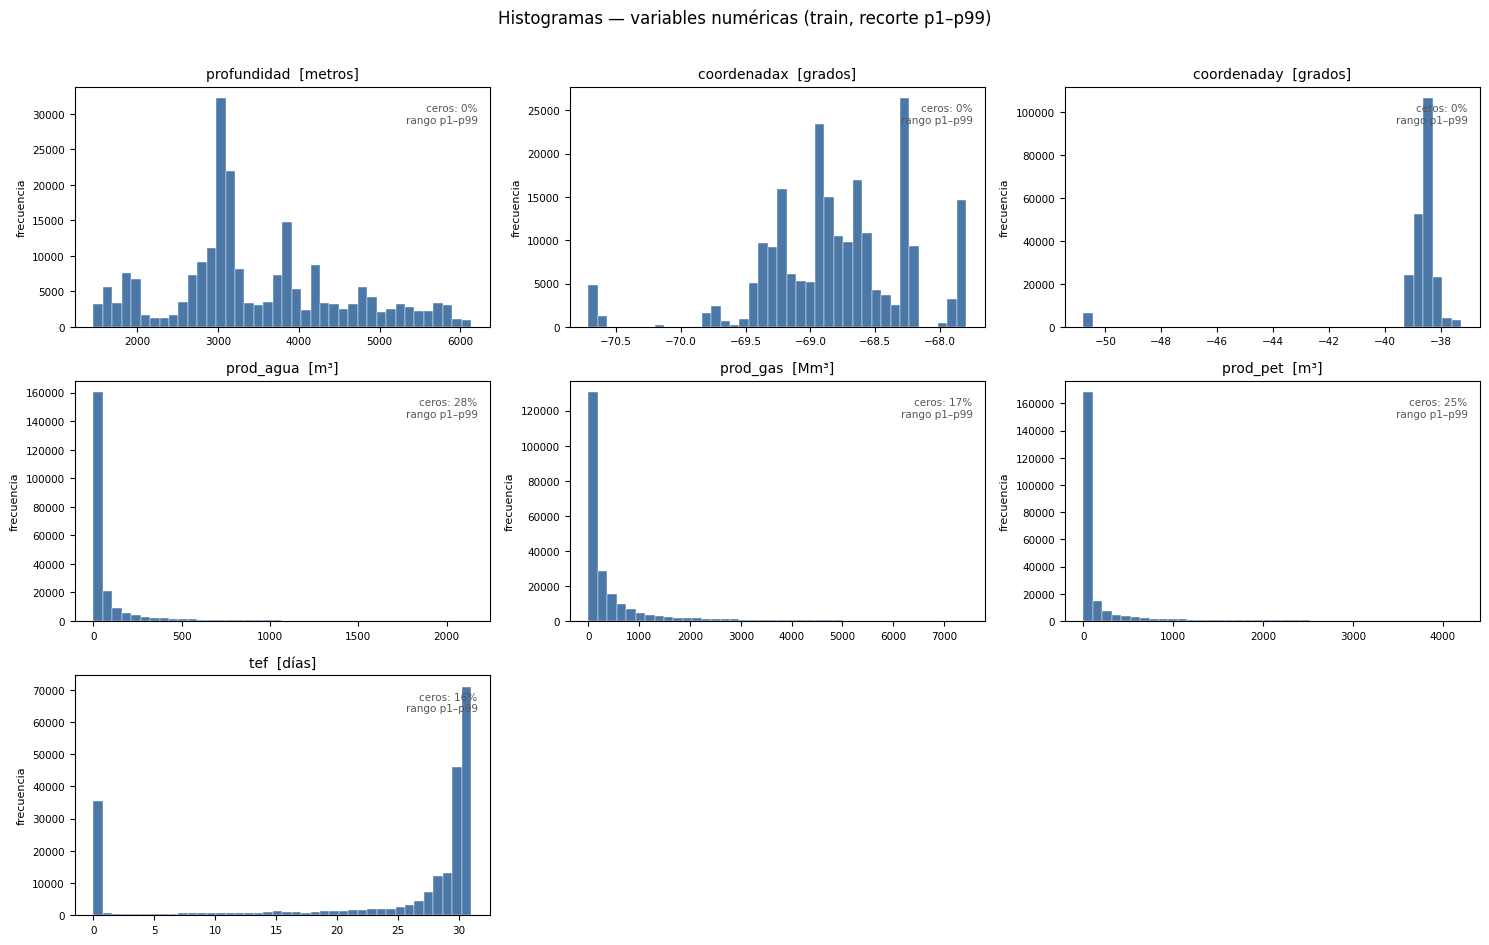

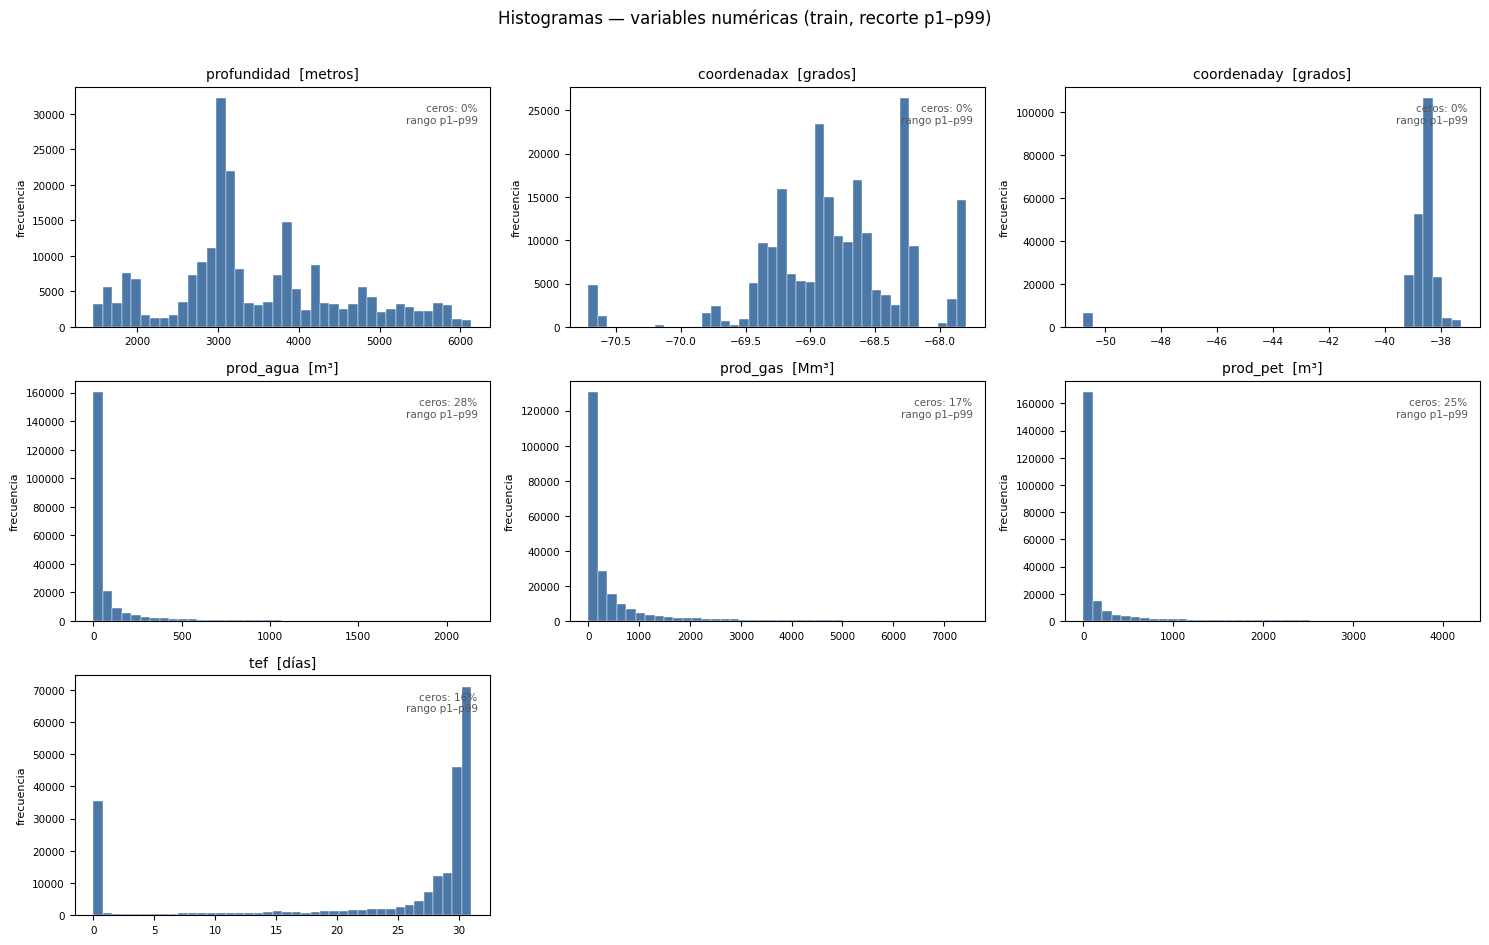

In [8]:
eda.plot_numeric_histograms(train)

## 6. Frecuencias — variables categóricas

Frecuencia (% de filas de train) de las 14 categóricas que pasaron el filtro. Para las de **alta cardinalidad** (`empresa`, `areapermisoconcesion`, `areayacimiento`) se muestran las `top 15` categorías; el título indica cuántas quedaron fuera.

Cosas a mirar: categorías muy dominantes (`cuenca` ~96% NEUQUINA, `provincia` ~86% Neuquén, `clasificacion` ~89% EXPLOTACION) aportan poca variación; y `tipopozo` no es 100% Petrolífero aunque el universo sea petrolero, porque el tipo puede cambiar mes a mes y el universo se define con haber tenido `prod_pet > 0` **al menos un mes**.

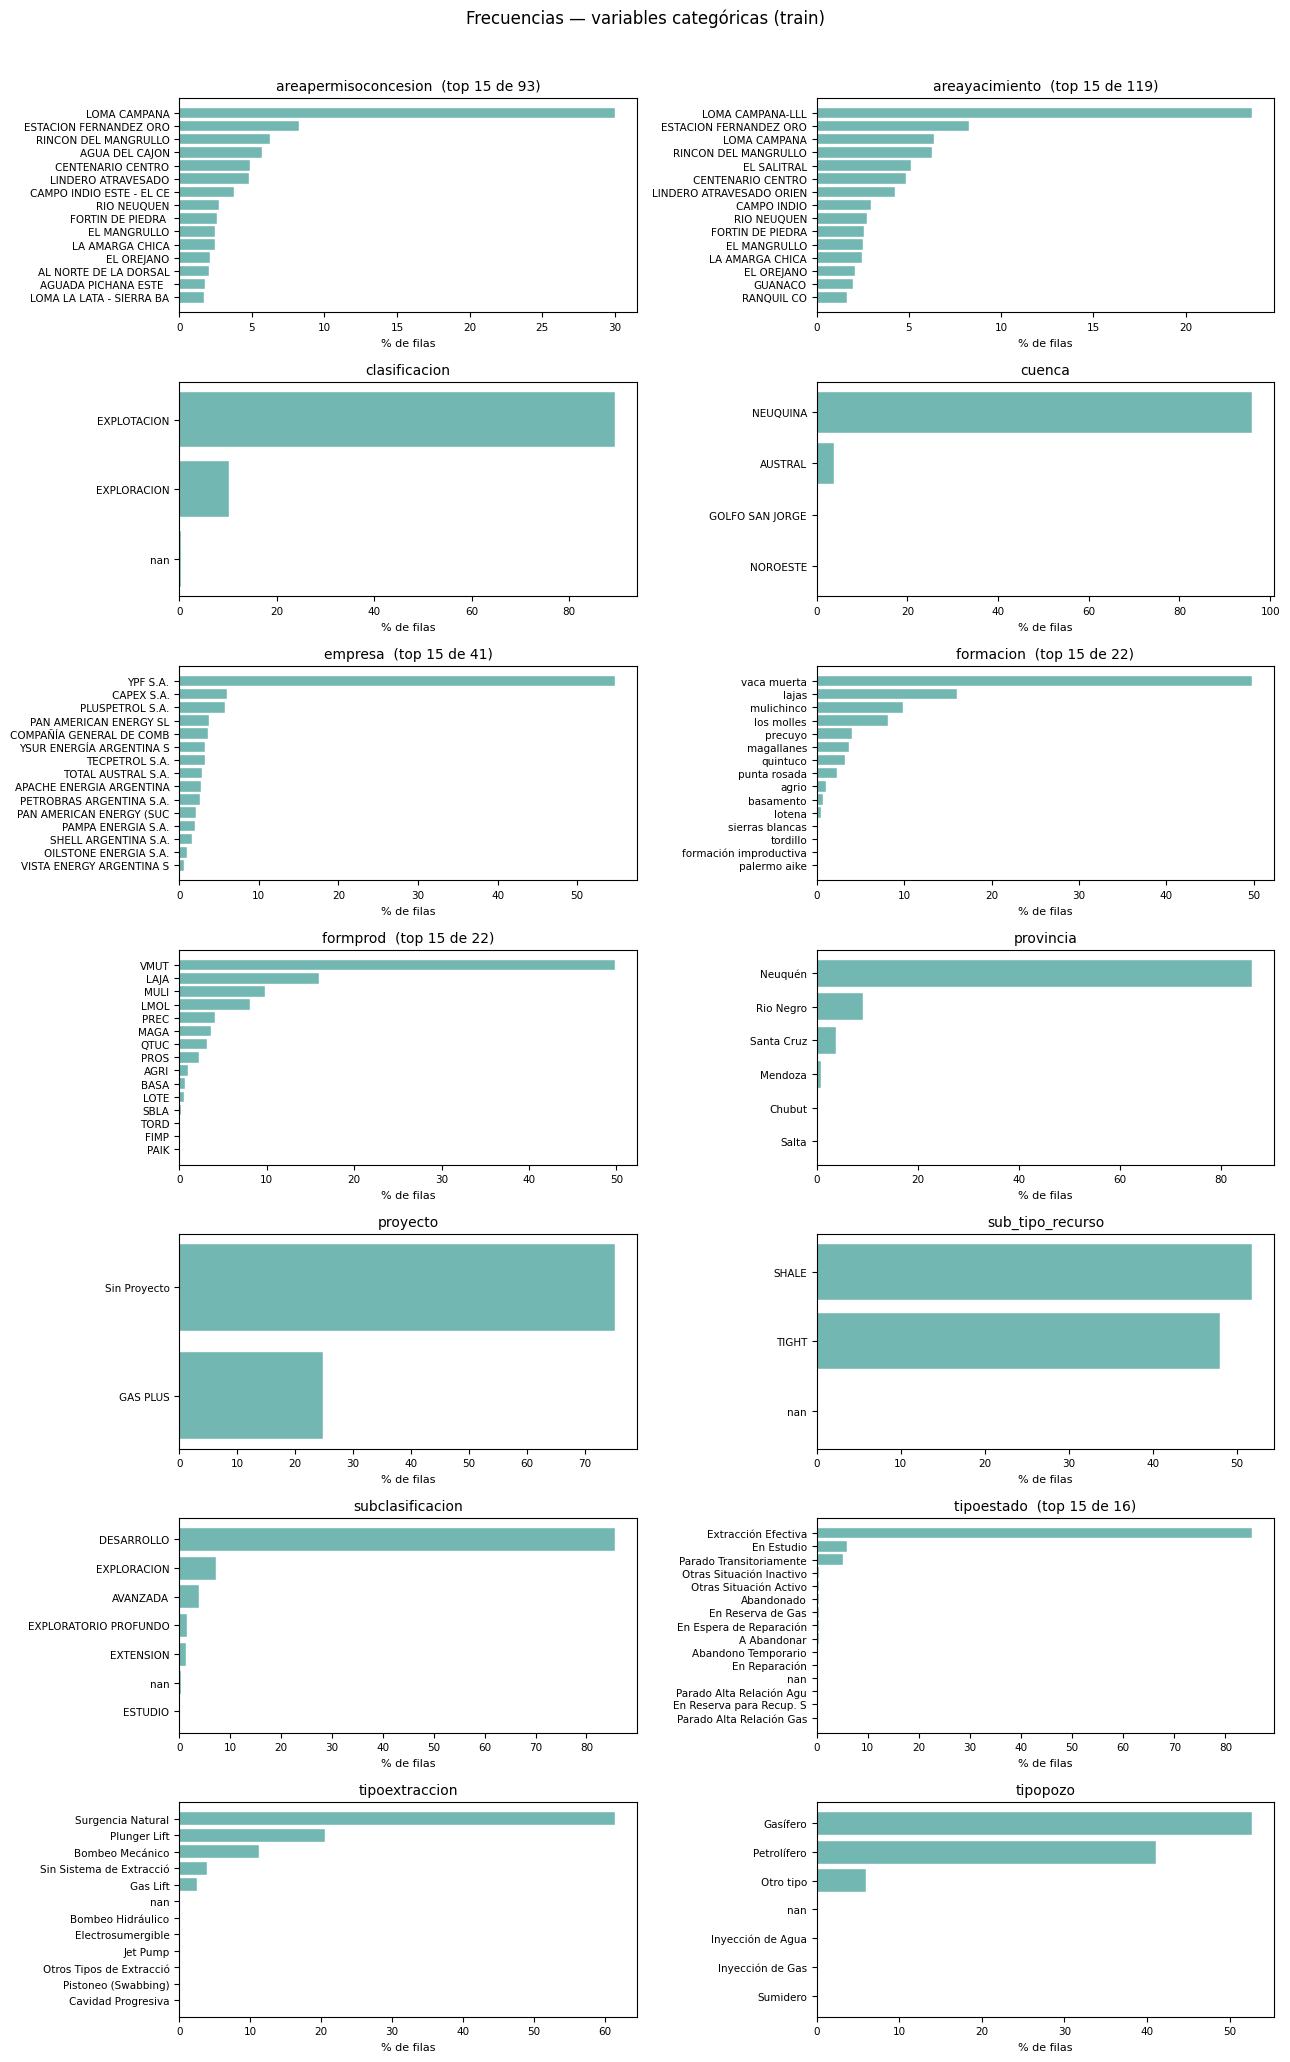

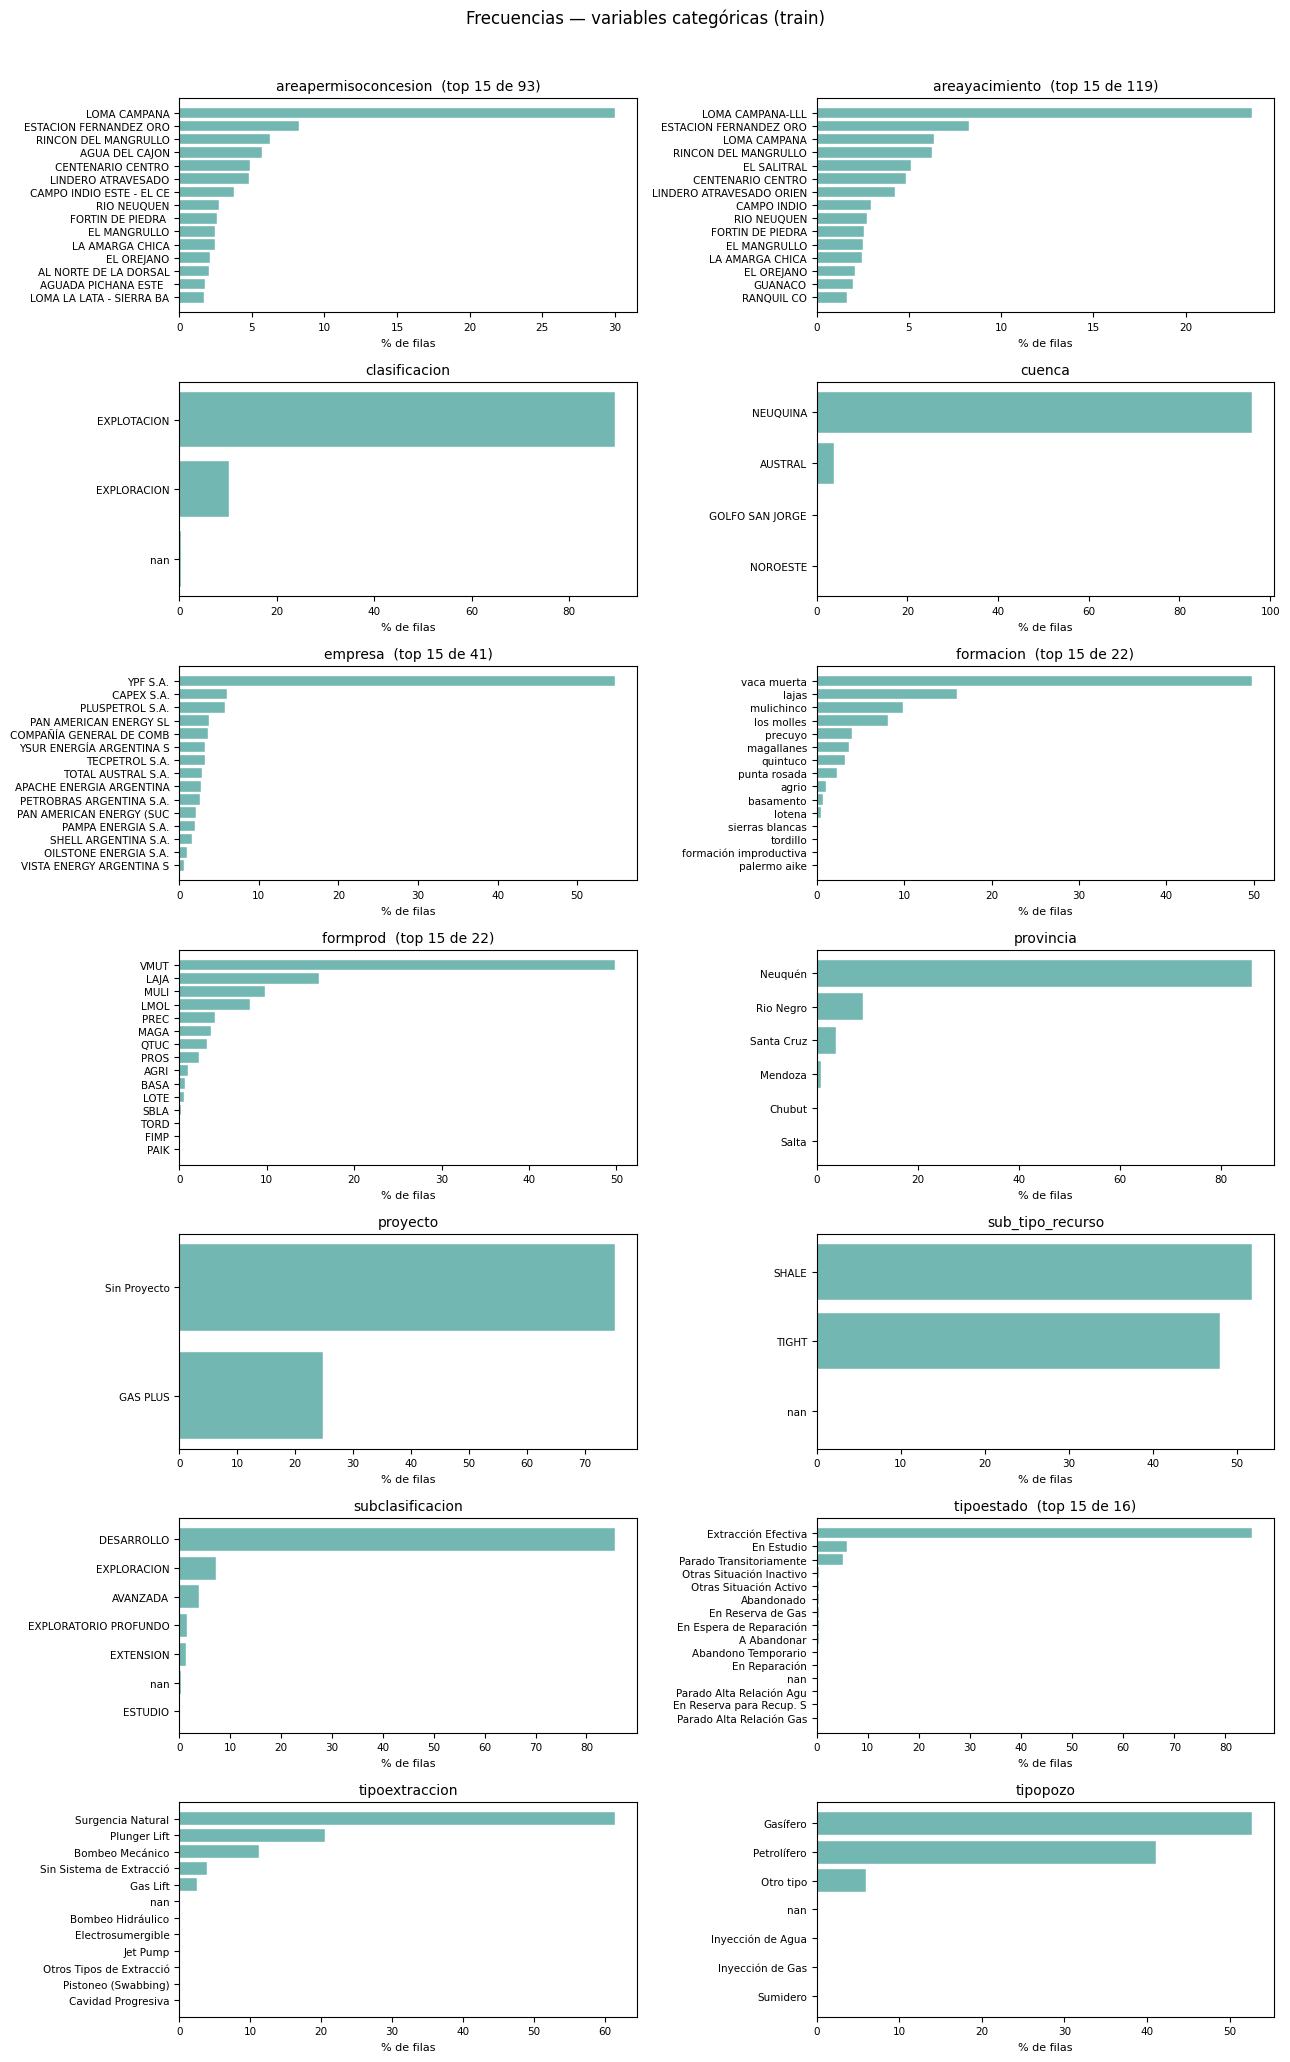

In [9]:
eda.plot_categorical_frequencies(train)

## 7. ¿Qué columnas entran al modelo?

**Ojo: esto es una decisión distinta de la de la sección 4.** Ahí decidimos qué *graficar* en el EDA; acá decidimos qué *usar como input* del modelo. No es lo mismo, y hay columnas que cambian de lado:

- Los **identificadores** (`idpozo`, `idempresa`, `idarea*`) los descartamos del EDA porque no se distribuyen, pero **no** se tiran: son la **clave** para construir el panel y las features (lags y agregados por pozo / empresa / área). Por eso van como `feature_engineering` — no entran crudos al modelo, pero el feature engineering se apoya en ellos.
- `anio` y `mes` los sacamos del EDA por ser el eje temporal, pero **sí** son candidatos a **input**: `mes` aporta estacionalidad (mejor codificado cíclico, sin/cos) y `anio` tendencia (con cuidado: predecir años fuera de train es extrapolación).

A diferencia de la sección 4, esta clasificación **no se deriva sola de los datos**: es una decisión de diseño, así que va curada a mano en `ml.eda.MODEL_INPUT_ROLE` (con los stats al lado como apoyo). Categorías de `uso_modelo`:

- **`target`** → `prod_pet` (lo que se predice).
- **`input`** → candidata a entrar como feature.
- **`feature_engineering`** → no entra cruda, pero arma el panel / las features.
- **`descartar`** → no aporta (constante, casi vacía o metadata de carga).

In [10]:
eda.model_input_plan(train)

,rol,dtype,n_unique,pct_null,pct_dominante,uso_modelo,motivo_modelo
columna,,,,,,,
prod_pet,medida,float64,83477,0.00,25.2,target,lo que se predice (t+1).
profundidad,atributo_pozo,float64,1903,0.00,1.6,input,atributo estático del pozo (proxy de geología).
areapermisoconcesion,categórica,object,93,0.00,30.0,input,área; alta cardinalidad -> encoding cuidadoso.
areayacimiento,categórica,object,119,0.00,23.6,input,yacimiento; alta cardinalidad -> encoding cuidadoso.
clasificacion,categórica,object,2,0.35,89.4,input,explotación/exploración; encodear.
cuenca,categórica,object,4,0.00,96.1,input,casi constante (NEUQUINA); aporta poco.
empresa,categórica,object,41,0.00,54.7,input,operadora; alta cardinalidad -> target/freq encoding.
formacion,categórica,object,22,0.00,49.8,input,formación geológica; encodear.
formprod,categórica,object,22,0.00,49.8,input,formación productiva; encodear.


**Lectura.** Quedan **22 columnas candidatas a input** (6 numéricas + 2 temporales + 14 categóricas), **4 como `feature_engineering`** (las claves), `prod_pet` como **target** y **13 descartadas** (inyecciones constantes, metadata de carga y columnas casi vacías).

Esto es una **lista de candidatas, no la lista final**: el recorte fino (qué encoding para las categóricas de alta cardinalidad, si `anio` entra o no por la extrapolación, qué lags de las medidas) se decide en el modelado. La construcción real del frame de features vive en `ml/dataset.py`; esta tabla es la justificación documentada de qué se incluye y por qué.

## 8. Correlación entre las features numéricas

Matriz de correlación de las **features numéricas candidatas** (`uso_modelo == 'input'`), con el target `prod_pet` en la primera fila/columna. Sirve para dos cosas: ver qué tan **relacionada con el target** está cada numérica, y detectar **pares muy correlacionados entre sí** (redundancia / multicolinealidad).

> Correlación de Pearson (lineal). Dada la fuerte asimetría de las medidas de producción, `eda.plot_numeric_correlation(train, method="spearman")` (de rango) suele ser más representativa de relaciones monótonas; la dejo como variante.

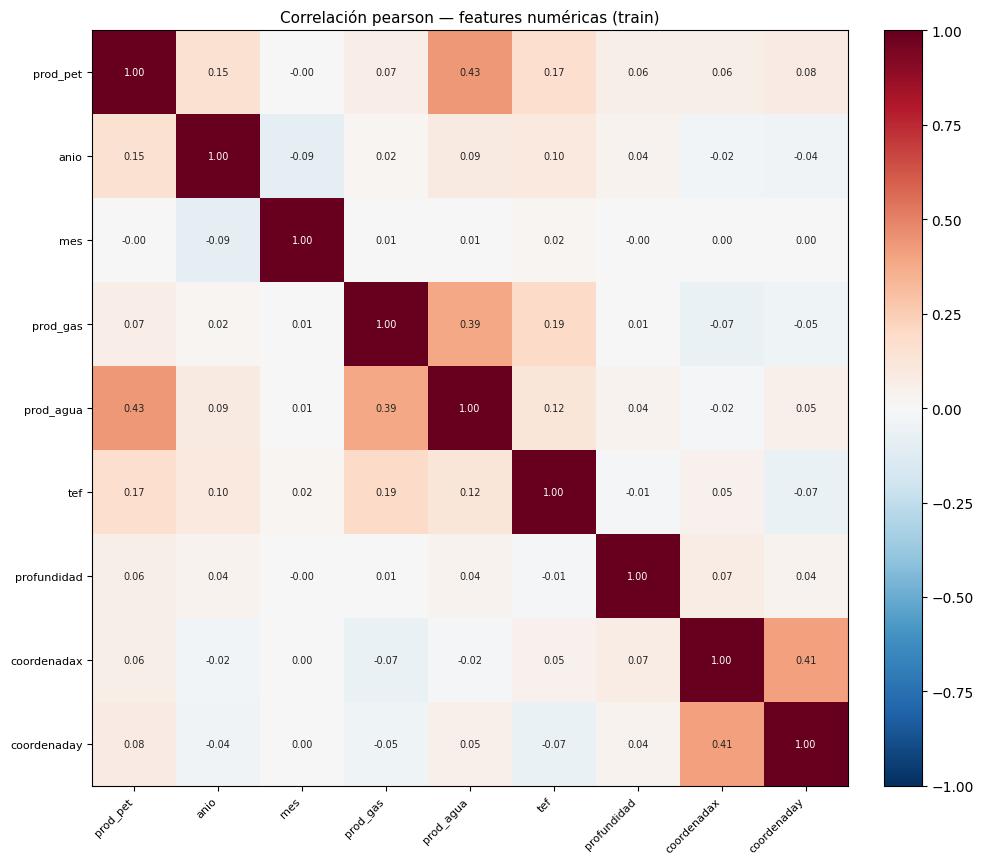

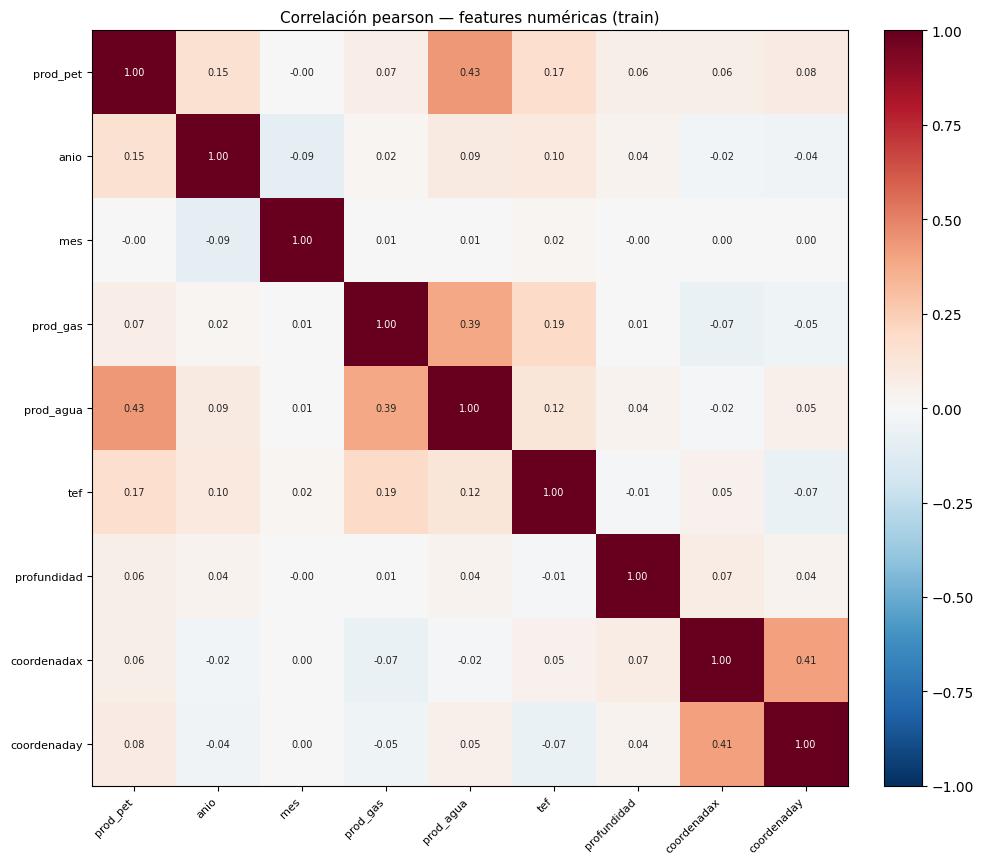

In [11]:
eda.plot_numeric_correlation(train)

**Lectura.** Ninguna numérica es por sí sola un predictor fuerte de `prod_pet` (todo lo contemporáneo es correlación débil, lo esperable: la señal real para el forecast t+1 vendrá de los **lags** del propio pozo). Lo más destacable:

- `prod_agua` es la más correlacionada con el target (**~0.43**): los pozos que producen más petróleo tienden a producir más agua.
- `prod_gas`–`prod_agua` (**~0.39**) y `coordenadax`–`coordenaday` (**~0.41**) están correlacionadas entre sí (las coords obvio, por la geografía de la cuenca) → hay algo de redundancia a tener en cuenta.
- `mes` ≈ 0 con todo: la estacionalidad **no** se captura con el mes como número lineal (1–12), confirma que conviene codificarlo **cíclico** (sin/cos).
- `tef` (~0.17) y `anio` (~0.15) aportan algo; `profundidad` y las coords, poco de forma lineal.

## 9. Correlación de las categóricas (one-hot) con el target

Las categóricas no tienen correlación directa con un número, así que primero las pasamos a **one-hot** (`pd.get_dummies`: una columna 0/1 por categoría) y calculamos la correlación de cada dummy con `prod_pet` (correlación **punto-biserial** = Pearson entre una binaria y una continua).

`eda.categorical_target_correlation(train)` devuelve la tabla larga completa (`feature / categoria / pct_filas / corr_target`, una fila por categoría de las 14 features); el gráfico muestra las **top 25 por |correlación|**. La columna `pct_filas` ayuda a no sobre-interpretar: una categoría con correlación alta pero presente en muy pocas filas puede ser un nicho, no una señal robusta.

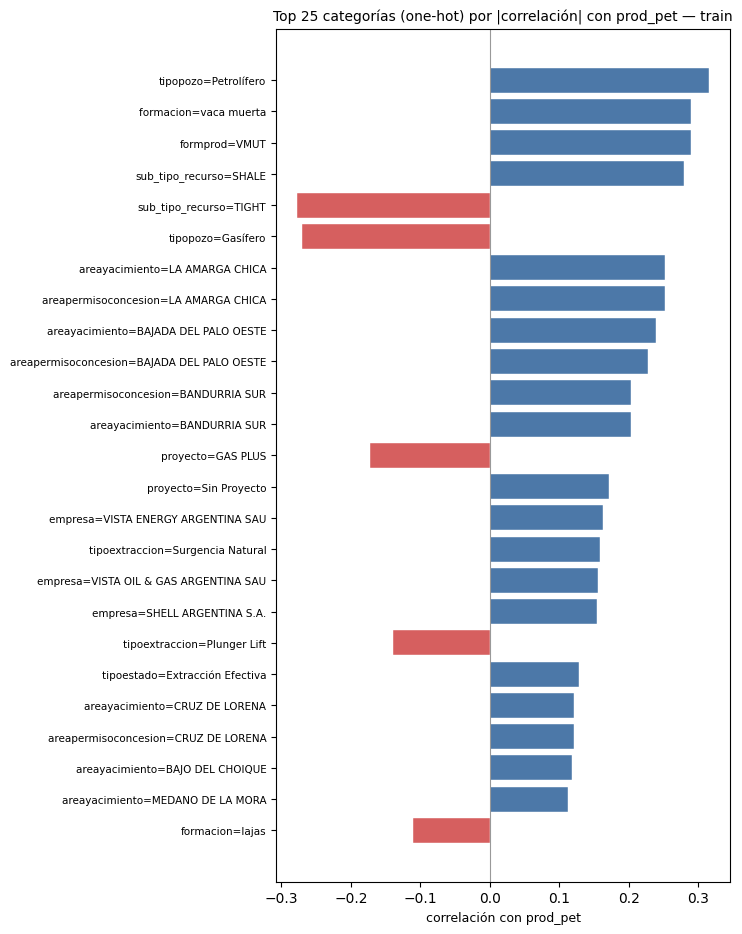

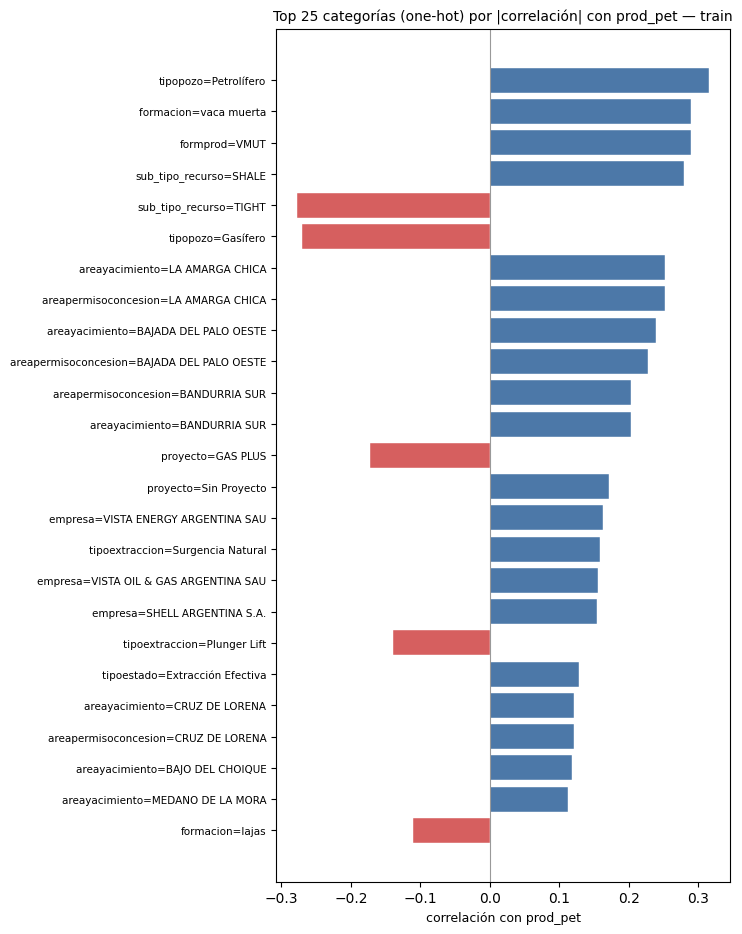

In [12]:
eda.plot_categorical_target_correlation(train)

In [13]:
# Tabla larga completa (todas las categorías one-hot, ordenadas por |corr|)
eda.categorical_target_correlation(train).head(30)

,feature,categoria,pct_filas,corr_target
0,tipopozo,Petrolífero,41.1,0.316
1,formacion,vaca muerta,49.8,0.290
2,formprod,VMUT,49.8,0.290
3,sub_tipo_recurso,SHALE,51.8,0.279
4,sub_tipo_recurso,TIGHT,48.0,-0.278
5,tipopozo,Gasífero,52.8,-0.271
6,areayacimiento,LA AMARGA CHICA,2.5,0.252
7,areapermisoconcesion,LA AMARGA CHICA,2.5,0.252
8,areayacimiento,BAJADA DEL PALO OESTE,0.4,0.239
9,areapermisoconcesion,BAJADA DEL PALO OESTE,1.0,0.227


**Lectura.** Las categóricas separan el target **bastante mejor que las numéricas contemporáneas**: las correlaciones top llegan a ~0.3, y casi todas las de arriba son distintas formas de decir lo mismo — **petróleo vs gas / convencional vs no convencional**:

- `tipopozo=Petrolífero` (**+0.32**) vs `tipopozo=Gasífero` (**−0.27**): la señal más fuerte y la más esperable (un pozo gasífero produce menos petróleo).
- `formacion=vaca muerta` / `formprod=VMUT` (**+0.29**) y `sub_tipo_recurso=SHALE` (**+0.28**) vs `TIGHT` (**−0.28**): la geología de Vaca Muerta / shale se asocia a más petróleo. Ojo que `formacion` y `formprod` son casi la misma info (correlaciones idénticas) → redundantes entre sí.
- Yacimientos puntuales (`LA AMARGA CHICA`, `BAJADA DEL PALO OESTE`, `BANDURRIA SUR`) aparecen alto pero con `pct_filas` chico (0.4–2.5%): señal real de áreas muy productivas, pero **de nicho**; con one-hot puro generan muchas columnas ralas → es justo el caso donde conviene **target/frequency encoding** en vez de one-hot.

**Conclusión del EDA de features:** los mejores predictores estáticos son **tipo de pozo, formación/recurso y área**; las numéricas contemporáneas aportan poco por sí solas y la fuerza del modelo va a venir de los **lags del propio pozo** (a construir en `ml/dataset.py`).

## 10. Construcción del dataset básico procesado

Con las features candidatas decididas, armamos el **dataset básico ya procesado** que va a comer el modelo. La construcción vive en `ml.dataset.build_basic_dataset`; acá lo generamos, lo inspeccionamos y lo guardamos como CSV local.

**El punto clave es el anti-leakage temporal.** Predecimos `prod_pet` del **mes que viene (t+1)**, así que **todos los features tienen que ser del mes anterior** al que se predice — nunca del mismo mes. El diseño:

- Cada fila es `(pozo, mes t)`. **Todos los features son del mes t**; el target `y_next` es `prod_pet` del **mes t+1**.
- Por construcción, ningún feature usa información del mes que se predice. En particular `prod_pet` del mes t queda como feature = **"producción de petróleo del mes anterior"** (lo que pediste), y lo mismo `prod_agua`, `prod_gas`, `tef`, etc. del mes t.
- El target se arma por **merge de calendario** (`periodo + 1 mes`), no por `shift(-1)` de filas: si un pozo tiene un **hueco** en su serie mensual, no se arma un par (features t, target t+k) con k≠1 — esa fila se descarta. Así `y_next` es **siempre** exactamente el mes siguiente.
- **Universo petrolero definido solo con train** (pozos con `prod_pet > 0` en algún mes ≤ TRAIN_END). Si se definiera sobre todo el histórico, la pertenencia al universo usaría datos de val/test (leak de selección). Es el mismo universo del EDA → **3.018 pozos**.
- `mes` queda como el mes de los features (t); para estacionalidad conviene codificarlo cíclico (sin/cos) en el modelado.

> **Sobre predecir 0:** el filtro de universo **no** saca los meses en 0 — un pozo petrolero parado sigue siendo una fila válida con `y_next = 0` (de hecho ~25% de los targets son 0). Lo único que se deja afuera son pozos que **nunca** son petroleros (gas/inyección, oil ≡ 0), que no son el objetivo del forecast. El modelo sí aprende a predecir 0.

> El CSV se guarda bajo `data/` (gitignoreado por `data/.gitignore`), así que es un **derivado local** que no se versiona ni toca el crudo original.

In [14]:
ds = dataset.build_basic_dataset()

print(f"Filas:   {len(ds):,}")
print(f"Pozos:   {ds['idpozo'].nunique():,}")
print(f"Columnas: {ds.shape[1]}  ({len(dataset.BASIC_NUMERIC_FEATURES)} numéricas + "
      f"{len(dataset.BASIC_CATEGORICAL_FEATURES)} categóricas + claves + y_next)")
print(f"Rango (mes de los features): {ds['periodo'].min().date()} -> {ds['periodo'].max().date()}")
print("\nFilas por split (ADR-028):")
print(ds['split'].value_counts().reindex(['train', 'val', 'test']).to_string())

Filas:   319,560
Pozos:   3,018
Columnas: 28  (9 numéricas + 14 categóricas + claves + y_next)
Rango (mes de los features): 2006-01-01 -> 2026-03-01

Filas por split (ADR-028):
split
train    223621
val       47883
test      48056


**Chequeo del desfasaje t / t+1.** Para un pozo cualquiera mostramos `periodo` (mes de los features), `prod_pet` (la producción de ese mes, = "mes anterior" relativa al target), `periodo_objetivo` (mes que se predice) y `y_next` (target). Se ve que `y_next` de una fila coincide con `prod_pet` de la fila siguiente: el target es literalmente la producción del mes que viene.

In [15]:
pozo_ej = ds["idpozo"].iloc[0]
ds.loc[ds["idpozo"] == pozo_ej,
       ["idpozo", "periodo", "prod_pet", "periodo_objetivo", "y_next"]].head(8)

,idpozo,periodo,prod_pet,periodo_objetivo,y_next
0,3640,2006-02-01,0.000,2006-03-01,30.808
1,3640,2006-03-01,30.808,2006-04-01,76.609
2,3640,2006-04-01,76.609,2006-05-01,63.273
3,3640,2006-05-01,63.273,2006-06-01,55.043
4,3640,2006-06-01,55.043,2006-07-01,58.862
5,3640,2006-07-01,58.862,2006-08-01,33.241
6,3640,2006-08-01,33.241,2006-09-01,37.288
7,3640,2006-09-01,37.288,2006-10-01,64.166


In [16]:
# Primeras filas del dataset, transpuesto para leer todas las columnas
ds.head(3).T

,0,1,2
idpozo,3640,3640,3640
periodo,2006-02-01 00:00:00,2006-03-01 00:00:00,2006-04-01 00:00:00
periodo_objetivo,2006-03-01 00:00:00,2006-04-01 00:00:00,2006-05-01 00:00:00
split,train,train,train
prod_pet,0.0,30.808,76.609
prod_gas,0.0,1.731,3.713
prod_agua,0.0,30.57,46.479
tef,0.0,10.41667,30.0
profundidad,2585.0,2585.0,2585.0
coordenadax,-68.45239,-68.45239,-68.45239


**Guardado.** Persistimos el dataset a un CSV local (gitignoreado). Esta es la fuente que va a usar el modelado; queda como derivado reproducible del crudo.

In [17]:
ruta = dataset.save_basic_dataset(ds)
print(f"Dataset básico guardado en: {ruta.relative_to(REPO_ROOT)}")
print(f"Tamaño: {ruta.stat().st_size / 1e6:.1f} MB  (gitignoreado por data/.gitignore)")

Dataset básico guardado en: data/processed/dataset_basico.csv
Tamaño: 88.5 MB  (gitignoreado por data/.gitignore)
